/home/km1612@students.ad.unt.edu/projects/llm-causality-test/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


[INFO] Device: cpu
[INFO] Dataset: 1826 obs × 5 variables
[INFO] Date range: 2021-01-01 → 2025-12-31

[INFO] Applying STL decomposition (period=365) ...
  ozone: seasonal range [-0.0337, 0.0320]
  T2M: seasonal range [-31.3293, 15.1716]
  RH2M: seasonal range [-34.1975, 27.1070]
  PRECTOTCORR: seasonal range [-22.6278, 97.2357]
  WS2M: seasonal range [-2.3140, 5.0340]

[INFO] Running TCDF causal discovery ...

TCDF — target: ozone  (idx=0)
  Epoch [001/300]  loss=1.197508
  Epoch [050/300]  loss=0.846115
  Epoch [100/300]  loss=0.696949
  Epoch [150/300]  loss=0.678593
  Epoch [200/300]  loss=0.636982
  Epoch [250/300]  loss=0.629127
  Epoch [300/300]  loss=0.628781

[INFO] Attention scores (raw): [1.3930563  0.29315466 1.1952333  0.4652657  0.49751437]
[INFO] first_loss=1.197508, real_loss=0.628781
[INFO] Potential causes (pre-PIVM): ['ozone', 'RH2M']

[INFO] Running PIVM validation ...
  [PIVM] source idx=0 kept    (testdiff=0.323259 ≤ diff*sig=0.454982)
  [PIVM] source idx=2 kept   

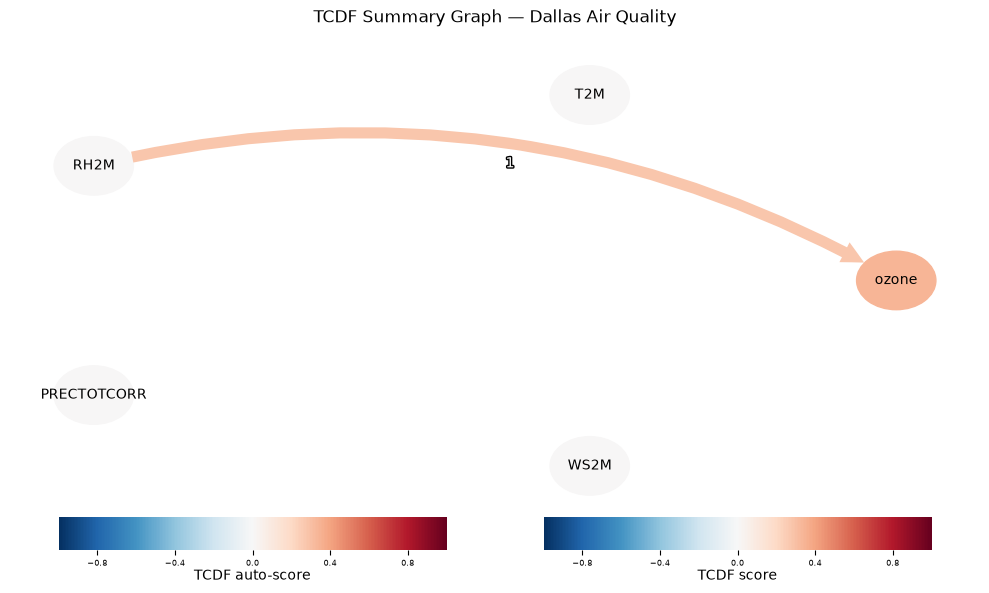

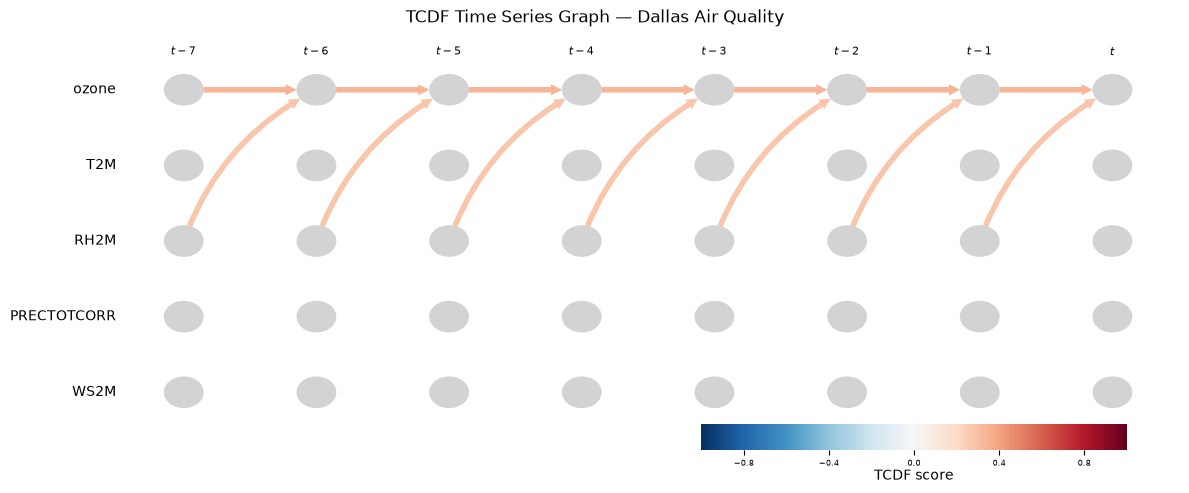

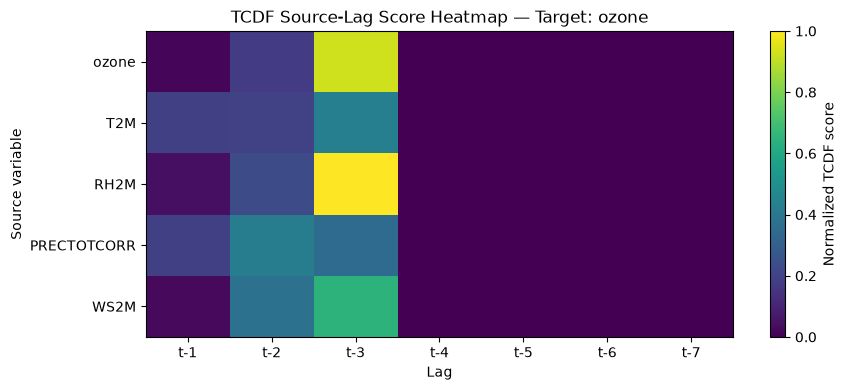

In [ ]:
"""
TCDF- Causal Discovery
=======================
Preprocessing: STL decomposition (period=365) to remove annual seasonality.
Scaling: StandardScaler.
Model: TCDF-style neural temporal model using M-Nauta/TCDF (GitHub).
Output: TCDF scores converted into Tigramite-style val_matrix and graph.
- TCDF does not produce p-values.
- TCDF edges are attention/PIVM-validated temporal links.
- Lag discovery is via kernel weight interpretation, not attention.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
import heapq
import copy
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

from tigramite import plotting as tp

# =============================================================================
# 1. Configuration
# =============================================================================
DATA_PATH   = "datasets/multipollutants_dallas_combined_with_Meteorology.csv"
#FIGURE_DIR  = "figures/"

TAU_MIN     = 1
TAU_MAX     = 7
ALPHA_LEVEL = 0.05    # used as 'significance' in PIVM validation
STL_PERIOD  = 365

COLS = [
    "ozone",
    "T2M",
    "RH2M",
    "PRECTOTCORR",
    "WS2M",
]

TARGET_VARS = ["ozone", "T2M", "RH2M", "PRECTOTCORR", "WS2M"]

# TCDF neural settings  (matched to original repo defaults)
SEED        = 42
EPOCHS      = 300
LR          = 0.01          # original uses 0.01
KERNEL_SIZE = 4             # original default
LEVELS      = 1             # num_levels (layers) in DepthwiseNet
DILATION_C  = 4             # dilation coefficient, original default
LOG_INTERVAL = 50

# PIVM significance: validated.remove(idx) if testdiff > diff * significance
# In original: significance=0.8 by default
SIGNIFICANCE = 0.8

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CUDA   = torch.cuda.is_available()

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"[INFO] Device: {DEVICE}")

# =============================================================================
# 2. Load and sort
# =============================================================================
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

data_raw = df[COLS].dropna().copy()
print(f"[INFO] Dataset: {len(data_raw)} obs × {len(COLS)} variables")
print(f"[INFO] Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")

# =============================================================================
# 3. STL decomposition — remove annual seasonal cycle, retain residuals
# =============================================================================
print("\n[INFO] Applying STL decomposition (period=365) ...")

residuals = {}
for col in COLS:
    stl = STL(data_raw[col], period=STL_PERIOD, robust=True)
    res = stl.fit()
    residuals[col] = res.resid
    print(f"  {col}: seasonal range [{res.seasonal.min():.4f}, {res.seasonal.max():.4f}]")

data_deseason = pd.DataFrame(residuals)

# =============================================================================
# 4. Standardize
# =============================================================================
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_deseason).astype(np.float32)

# =============================================================================
# 5. Prepare data in TCDF format
#    Original preparedata(): shape [1, n_vars, T] for X, [1, T, 1] for Y
#    Target column in X is replaced with its lag-1 shift (to avoid self-leak).
# =============================================================================
def prepare_data(data_array, target_idx):
    """
    Matches original TCDF preparedata():
      - X: [1, n_vars, T]  — target col replaced with lag-1 of itself
      - Y: [1, T, 1]
    """
    T, V = data_array.shape

    df_x = data_array.copy()                    # [T, V]
    df_y = data_array[:, target_idx].copy()     # [T]

    # Replace target column in X with its lag-1 (fill t=0 with 0)
    target_lagged = np.zeros(T, dtype=np.float32)
    target_lagged[1:] = data_array[:-1, target_idx]
    df_x[:, target_idx] = target_lagged

    # [1, V, T]
    X = torch.from_numpy(df_x.T[np.newaxis, :, :])
    # [1, T, 1]
    Y = torch.from_numpy(df_y[np.newaxis, :, np.newaxis])

    X = Variable(X)
    Y = Variable(Y)

    return X, Y

# =============================================================================
# 6. Faithful TCDF architecture
#    Chomp1d  →  causal masking (future leak fix)
#    DepthwiseCausalNet  →  dilated depthwise conv layers
#    ADDSTCN  →  attention × depthwise + pointwise head
# =============================================================================

class Chomp1d(nn.Module):
    """Removes future padding to enforce causality."""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()


class FirstBlock(nn.Module):
    def __init__(self, target, n_inputs, n_outputs, kernel_size, stride, dilation, padding):
        super().__init__()
        self.target = target
        self.conv1 = nn.Conv1d(
            n_inputs, n_outputs, kernel_size,
            stride=stride, padding=padding,
            dilation=dilation, groups=n_outputs   # depthwise
        )
        self.chomp1 = Chomp1d(padding)
        self.net    = nn.Sequential(self.conv1, self.chomp1)
        self.relu   = nn.PReLU(n_inputs)
        self._init_weights()

    def _init_weights(self):
        self.conv1.weight.data.normal_(0, 0.1)

    def forward(self, x):
        return self.relu(self.net(x))


class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding):
        super().__init__()
        self.conv1 = nn.Conv1d(
            n_inputs, n_outputs, kernel_size,
            stride=stride, padding=padding,
            dilation=dilation, groups=n_outputs
        )
        self.chomp1 = Chomp1d(padding)
        self.net    = nn.Sequential(self.conv1, self.chomp1)
        self.relu   = nn.PReLU(n_inputs)
        self._init_weights()

    def _init_weights(self):
        self.conv1.weight.data.normal_(0, 0.1)

    def forward(self, x):
        return self.relu(self.net(x) + x)   # residual


class LastBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding):
        super().__init__()
        self.conv1 = nn.Conv1d(
            n_inputs, n_outputs, kernel_size,
            stride=stride, padding=padding,
            dilation=dilation, groups=n_outputs
        )
        self.chomp1 = Chomp1d(padding)
        self.net    = nn.Sequential(self.conv1, self.chomp1)
        self.linear = nn.Linear(n_inputs, n_inputs)
        self._init_weights()

    def _init_weights(self):
        self.linear.weight.data.normal_(0, 0.01)

    def forward(self, x):
        out = self.net(x)
        # residual in time dimension, then linear
        return self.linear(
            (out + x).transpose(1, 2)
        ).transpose(1, 2)


class DepthwiseCausalNet(nn.Module):
    def __init__(self, target, num_inputs, num_levels, kernel_size=2, dilation_c=2):
        super().__init__()
        layers = []
        for l in range(num_levels):
            dilation_size = dilation_c ** l
            padding = (kernel_size - 1) * dilation_size
            if l == 0:
                layers.append(FirstBlock(target, num_inputs, num_inputs,
                                         kernel_size, stride=1,
                                         dilation=dilation_size, padding=padding))
            elif l == num_levels - 1:
                layers.append(LastBlock(num_inputs, num_inputs,
                                        kernel_size, stride=1,
                                        dilation=dilation_size, padding=padding))
            else:
                layers.append(TemporalBlock(num_inputs, num_inputs,
                                            kernel_size, stride=1,
                                            dilation=dilation_size, padding=padding))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class ADDSTCN(nn.Module):
    """
    Faithful to M-Nauta/TCDF model.py:
      - fs_attention: [n_vars, 1], softmax over dim=0 (across source variables)
      - depthwise causal net
      - pointwise 1×1 conv head
    """
    def __init__(self, target, input_size, num_levels, kernel_size, cuda, dilation_c):
        super().__init__()
        self.target = target

        self.dwn = DepthwiseCausalNet(
            target, input_size, num_levels,
            kernel_size=kernel_size, dilation_c=dilation_c
        )
        self.pointwise = nn.Conv1d(input_size, 1, 1)

        # Attention over source variables — shape [n_vars, 1], NOT [n_vars, lags]
        self._attention    = torch.ones(input_size, 1)
        self._attention    = Variable(self._attention, requires_grad=False)
        self.fs_attention  = nn.Parameter(self._attention.data)

        if cuda:
            self.dwn        = self.dwn.cuda()
            self.pointwise  = self.pointwise.cuda()
            self._attention = self._attention.cuda()

    def init_weights(self):
        self.pointwise.weight.data.normal_(0, 0.1)

    def get_attention(self):
        """Returns normalised attention scores, shape [n_vars]."""
        return F.softmax(self.fs_attention, dim=0).squeeze(-1)   # [n_vars]

    def forward(self, x):
        # x: [1, n_vars, T]
        # fs_attention: [n_vars, 1] → broadcast over T
        y1  = self.dwn(x * F.softmax(self.fs_attention, dim=0))
        y1  = self.pointwise(y1)
        return y1.transpose(1, 2)   # [1, T, 1]

# =============================================================================
# 7. Train one epoch (matches original train())
# =============================================================================
def train_one_epoch(epoch, X_train, Y_train, model, optimizer, epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss   = F.mse_loss(output, Y_train)
    loss.backward()
    optimizer.step()

    if epoch == 1 or epoch % LOG_INTERVAL == 0 or epoch == epochs:
        print(f"  Epoch [{epoch:03d}/{epochs}]  loss={loss.item():.6f}")

    return model.fs_attention.data, loss


def train_tcdf_model(X_train, Y_train, model):
    optimizer = optim.Adam(model.parameters(), lr=LR)

    scores, first_loss_t = train_one_epoch(1, X_train, Y_train, model, optimizer, EPOCHS)
    first_loss = first_loss_t.cpu().item()

    for ep in range(2, EPOCHS + 1):
        scores, last_loss_t = train_one_epoch(ep, X_train, Y_train, model, optimizer, EPOCHS)

    real_loss = last_loss_t.cpu().item()
    return scores, first_loss, real_loss

# =============================================================================
# 8. PIVM validation (matches original findcauses() PIVM block)
#    Shuffles source column in X and checks if MSE degrades.
# =============================================================================
def pivm_validate(potentials, X_train, Y_train, model, first_loss, real_loss):
    validated = copy.deepcopy(potentials)
    diff = first_loss - real_loss

    for idx in potentials:
        random.seed(SEED)
        X_test = X_train.clone().cpu().numpy()
        random.shuffle(X_test[:, idx, :][0])       # shuffle time axis for source idx
        shuffled = torch.from_numpy(X_test)
        if CUDA:
            shuffled = shuffled.cuda()

        model.eval()
        with torch.no_grad():
            output   = model(shuffled)
            testloss = F.mse_loss(output, Y_train).cpu().item()

        testdiff = first_loss - testloss

        if testdiff > (diff * SIGNIFICANCE):
            validated.remove(idx)
            print(f"  [PIVM] source idx={idx} removed (testdiff={testdiff:.6f} > diff*sig={diff*SIGNIFICANCE:.6f})")
        else:
            print(f"  [PIVM] source idx={idx} kept    (testdiff={testdiff:.6f} ≤ diff*sig={diff*SIGNIFICANCE:.6f})")

    return validated

# =============================================================================
# 9. Lag discovery via kernel weight interpretation
#    Matches original findcauses() weight-reading block exactly.
# =============================================================================
def discover_lags(model, validated, target_idx):
    """
    Returns causeswithdelay: {(target_idx, source_idx): tau}
    Reads absolute conv kernel weights per layer, finds argmax,
    multiplies by dilation to get lag contribution.
    """
    weights = []
    for layer in range(LEVELS):
        w = model.dwn.network[layer].net[0].weight.abs()
        # shape: [n_vars, 1, kernel_size] → [n_vars, kernel_size]
        w = w.view(w.size(0), w.size(2))
        weights.append(w)

    causeswithdelay = {}

    for v in validated:
        total_delay = 0
        for k, w in enumerate(weights):
            row = w[v].tolist()
            two_largest = heapq.nlargest(2, row)
            m, m2 = two_largest[0], two_largest[1]
            if m > m2:
                index_max = len(row) - 1 - max(range(len(row)), key=row.__getitem__)
            else:
                index_max = 0
            delay = index_max * (DILATION_C ** k)
            total_delay += delay

        if target_idx != v:
            causeswithdelay[(target_idx, v)] = total_delay
        else:
            causeswithdelay[(target_idx, v)] = total_delay + 1   # self-cause gets +1

    return causeswithdelay

# =============================================================================
# 10. Attention threshold — gap-based selection (matches original findcauses())
#     Identifies potentials from sorted attention scores using largest gap.
# =============================================================================
def select_potentials_by_gap(scores_np):
    """
    scores_np: 1-D array of attention values, length = n_vars.
    Returns list of source indices that are potential causes.
    """
    s       = sorted(scores_np.tolist(), reverse=True)
    indices = np.argsort(-scores_np).tolist()

    if len(s) <= 5:
        potentials = [i for i in indices if scores_np[i] > 1.0]
        return potentials

    gaps     = []
    for i in range(len(s) - 1):
        if s[i] < 1.0:
            break
        gaps.append(s[i] - s[i + 1])

    sort_gaps = sorted(gaps, reverse=True)
    ind = -1

    for i in range(len(gaps)):
        largest_gap = sort_gaps[i]
        idx_gap     = gaps.index(largest_gap)
        if idx_gap < ((len(s) - 1) / 2) and idx_gap > 0:
            ind = idx_gap
            break

    if ind < 0:
        ind = 0

    potentials = indices[:ind + 1]
    return potentials

# =============================================================================
# 11. Run TCDF causal discovery
# =============================================================================
print("\n[INFO] Running TCDF causal discovery ...")

n_vars = len(COLS)

# Tigramite-style containers
tcdf_val_matrix = np.zeros((n_vars, n_vars, TAU_MAX + 1), dtype=float)
tcdf_graph      = np.empty((n_vars, n_vars, TAU_MAX + 1), dtype="<U3")
tcdf_graph[:]   = ""

# Score heatmaps for plotting: [n_vars, TAU_MAX] per target
target_score_maps = {}

for target_name in TARGET_VARS:
    target_idx = COLS.index(target_name)

    print("\n" + "=" * 60)
    print(f"TCDF — target: {target_name}  (idx={target_idx})")
    print("=" * 60)

    X_train, Y_train = prepare_data(data_scaled, target_idx)

    if CUDA:
        X_train = X_train.cuda()
        Y_train = Y_train.cuda()

    model = ADDSTCN(
        target     = target_idx,
        input_size = n_vars,
        num_levels = LEVELS,
        kernel_size= KERNEL_SIZE,
        cuda       = CUDA,
        dilation_c = DILATION_C
    )
    if CUDA:
        model = model.cuda()

    # --- Train ---
    scores_raw, first_loss, real_loss = train_tcdf_model(X_train, Y_train, model)

    # scores_raw: fs_attention.data, shape [n_vars, 1]
    scores_np = scores_raw.view(-1).cpu().numpy()   # [n_vars]

    print(f"\n[INFO] Attention scores (raw): {scores_np}")
    print(f"[INFO] first_loss={first_loss:.6f}, real_loss={real_loss:.6f}")

    # --- Select potentials via gap method ---
    potentials = select_potentials_by_gap(scores_np)
    print(f"[INFO] Potential causes (pre-PIVM): {[COLS[i] for i in potentials]}")

    # --- PIVM validation ---
    print("\n[INFO] Running PIVM validation ...")
    validated = pivm_validate(potentials, X_train, Y_train, model, first_loss, real_loss)
    print(f"[INFO] Validated causes: {[COLS[i] for i in validated]}")

    # --- Lag discovery ---
    causes_with_delay = discover_lags(model, validated, target_idx)
    print(f"[INFO] Causes with delay: { {(COLS[t], COLS[s]): d for (t,s),d in causes_with_delay.items()} }")

    # --- Fill Tigramite matrices ---
    # Attention score used as link strength; tau from kernel interpretation
    attn_norm = F.softmax(torch.tensor(scores_np), dim=0).numpy()   # [n_vars], sums to 1

    for (tgt_idx, src_idx), tau in causes_with_delay.items():
        tau = max(1, min(tau, TAU_MAX))    # clip to valid range
        score = float(attn_norm[src_idx])
        tcdf_val_matrix[src_idx, tgt_idx, tau] = score
        tcdf_graph[src_idx, tgt_idx, tau]      = "-->"

    # --- Build score heatmap: [n_vars, TAU_MAX]
    #     Attention weight × kernel magnitude at each lag position
    model.eval()
    kernel_mags = np.zeros((n_vars, TAU_MAX), dtype=float)

    with torch.no_grad():
        for layer in range(LEVELS):
            w = model.dwn.network[layer].net[0].weight.abs()
            w = w.view(w.size(0), w.size(2)).cpu().numpy()   # [n_vars, kernel_size]
            for v in range(n_vars):
                row = w[v]
                for ki, kval in enumerate(row):
                    lag = ki * (DILATION_C ** layer)
                    if 1 <= lag <= TAU_MAX:
                        kernel_mags[v, lag - 1] += kval

    # Outer product: attention score × kernel magnitude → [n_vars, TAU_MAX]
    score_map = attn_norm[:, np.newaxis] * kernel_mags
    if score_map.max() > 0:
        score_map = score_map / score_map.max()

    target_score_maps[target_name] = score_map

# =============================================================================
# 12. Print TCDF causal links
# =============================================================================
print("\n" + "=" * 60)
print("TCDF causal links")
print("=" * 60)

for target_name in TARGET_VARS:
    target_idx = COLS.index(target_name)
    print(f"\nTarget: {target_name}")
    print("-" * 40)
    found_any = False

    for source_idx, source_name in enumerate(COLS):
        for tau in range(1, TAU_MAX + 1):
            score = tcdf_val_matrix[source_idx, target_idx, tau]
            if score > 0:
                found_any = True
                print(f"  {source_name}(t-{tau}) → {target_name}(t) | TCDF score={score:.4f}")

    if not found_any:
        print("  [none found]")

# =============================================================================
# 13. Summary graph
# =============================================================================
tp.plot_graph(
    val_matrix            = tcdf_val_matrix,
    graph                 = tcdf_graph,
    var_names             = COLS,
    link_colorbar_label   = "TCDF score",
    node_colorbar_label   = "TCDF auto-score",
    figsize               = (10, 6)
)
plt.suptitle("TCDF Summary Graph — Dallas Air Quality", fontsize=12)
plt.tight_layout()
#plt.savefig(f"{FIGURE_DIR}tcdf_graph.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================================================================
# 14. Time series graph
# =============================================================================
tp.plot_time_series_graph(
    val_matrix          = tcdf_val_matrix,
    graph               = tcdf_graph,
    var_names           = COLS,
    link_colorbar_label = "TCDF score",
    figsize             = (12, 5)
)
plt.suptitle("TCDF Time Series Graph — Dallas Air Quality", fontsize=12)
plt.tight_layout()
#plt.savefig(f"{FIGURE_DIR}tcdf_tsg.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================================================================
# 15. Source-lag score heatmap
# =============================================================================
for target_name in TARGET_VARS:
    score_map = target_score_maps[target_name]

    plt.figure(figsize=(9, 4))
    im = plt.imshow(score_map, aspect="auto", origin="upper")
    plt.colorbar(im, label="Normalized TCDF score")
    plt.xticks(
        ticks  = np.arange(TAU_MAX),
        labels = [f"t-{tau}" for tau in range(1, TAU_MAX + 1)]
    )
    plt.yticks(ticks=np.arange(len(COLS)), labels=COLS)
    plt.xlabel("Lag")
    plt.ylabel("Source variable")
    plt.title(f"TCDF Source-Lag Score Heatmap — Target: {target_name}")
    plt.tight_layout()
    #plt.savefig(f"{FIGURE_DIR}tcdf_heatmap_{target_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

#print(f"\n[INFO] Figures saved → {FIGURE_DIR}")